In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#### Import the data

In [2]:
df = pd.read_excel('C:\Adatok\SzKK\Emese csoportja\Viki CD38\cum.xlsx')

In [3]:
# add a new column with the names and correct superscripts
names = ['N&T CD38\u207b', 'N&T CD38\u207a', 'N&T CD38\u02B0\u2071\u1D4D\u02B0', 'NSW CD38\u207b', 'NSW CD38\u207a', 'CD27\u207a CD38\u207b', 
         'CD27\u207a CD38\u207a', 'ASC', 'CD27\u207b CD38\u207b', 'CD27\u207b CD38\u207a']

df['names'] = names

In [4]:
df.head()

,type,basal,EC50forMax,max,AUC,ending,names
0,N&T_CD38-,5381,3.856,1.990,1132.0,1.424,N&T CD38⁻
1,N&T_CD38+,5114,5.492,1.604,966.3,1.261,N&T CD38⁺
2,N&T_CD38high,8318,2.551,2.619,1372.0,1.558,N&T CD38ʰⁱᵍʰ
3,NSW_CD38-,8081,5.585,4.401,1779.0,2.417,NSW CD38⁻
4,NSW_CD38+,7206,1.890,2.829,1224.0,1.573,NSW CD38⁺


#### Correlation analysis

In [5]:
# define labels for the figure (with readable names)
labels = ['Basal Ca\u00b2\u207a activity', 'EC\u2085\u2080 for maximum', 'Maximum', 'AUC', 'Ending']

In [6]:
# set the font type to Arial for visualization (DejaVu Sans is required for + and - superscripts)
plt.rcParams['font.family'] = ['Arial', 'DejaVu Sans']

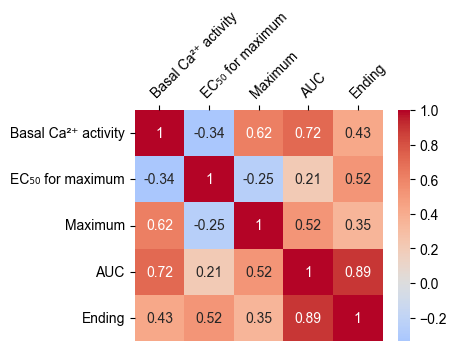

In [22]:
# plot
plt.figure(figsize=(4,3))
ax = sns.heatmap(df[['basal', 'EC50forMax', 'max', 'AUC', 'ending']].corr(), annot=True, cmap='coolwarm', center=0)
ticks1 = ax.get_xticks()
ticks2 = ax.get_yticks()
ax.xaxis.tick_top()
ax.set_xticks(ticks=ticks1, labels=labels, rotation=45, ha='left', rotation_mode='anchor')
ax.set_yticks(ticks=ticks2, labels=labels, rotation=0)

plt.savefig('pearson_heatmap.jpg', bbox_inches='tight', dpi=600)

#### Pattern analysis in the data

In [14]:
# since the raw data is on very different scales it has to be scaled properly

In [8]:
scaler = StandardScaler()

In [9]:
# scale the data
forSc = df.copy()
forSc = forSc[['basal', 'EC50forMax', 'max', 'AUC', 'ending']]

scaledRaw = scaler.fit_transform(forSc)

In [10]:
scaledRaw

array([[-1.65956358,  0.58224432, -1.31270207, -0.5722087 , -0.1424903 ],
       [-1.931523  ,  1.68678015, -1.69926218, -1.38586167, -0.61360429],
       [ 1.33198999, -0.2988188 , -0.68278934,  0.60628686,  0.24480586],
       [ 1.09058782,  1.74956856,  1.10179647,  2.60481891,  2.72754767],
       [ 0.19933505, -0.74508909, -0.47248462, -0.12045207,  0.28815991],
       [ 0.58843054, -0.47638171,  1.16889369,  0.13488864, -0.05867248],
       [ 0.02414022, -0.18269401,  0.87346563, -0.37579277, -0.44596864],
       [ 0.32869402, -1.22174086, -0.4154019 , -0.19901844, -1.20610961],
       [ 0.18201928,  0.06913476,  0.44584602, -0.61640228, -0.55290862],
       [-0.15411034, -1.16300332,  0.9926383 , -0.07625848, -0.24075948]])

In [11]:
# create a dataframe with the scaled raw data
scaled_df = pd.DataFrame(scaledRaw)
scaled_df.rename(columns={0:'basal', 1:'EC50forMax', 2:'max', 3:'AUC', 4:'ending'}, inplace=True)   # rename columns
scaled_df['names'] = df['names']   # add names info from the original df
scaled_df.set_index('names', inplace=True)   # set type as index for the clustermap

In [12]:
scaled_df

,basal,EC50forMax,max,AUC,ending
names,,,,,
N&T CD38⁻,-1.659564,0.582244,-1.312702,-0.572209,-0.142490
N&T CD38⁺,-1.931523,1.686780,-1.699262,-1.385862,-0.613604
N&T CD38ʰⁱᵍʰ,1.331990,-0.298819,-0.682789,0.606287,0.244806
NSW CD38⁻,1.090588,1.749569,1.101796,2.604819,2.727548
NSW CD38⁺,0.199335,-0.745089,-0.472485,-0.120452,0.288160
CD27⁺ CD38⁻,0.588431,-0.476382,1.168894,0.134889,-0.058672
CD27⁺ CD38⁺,0.024140,-0.182694,0.873466,-0.375793,-0.445969
ASC,0.328694,-1.221741,-0.415402,-0.199018,-1.206110
CD27⁻ CD38⁻,0.182019,0.069135,0.445846,-0.616402,-0.552909


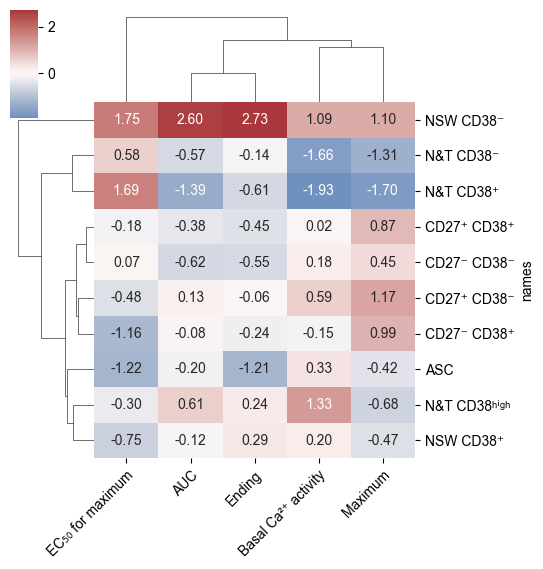

In [21]:
ax = sns.clustermap(scaled_df, figsize=(5.5,6), annot=True, fmt='.2f', cmap='vlag', center=0, xticklabels=labels)
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

plt.savefig('originalData_scaled_clustermap.jpg', bbox_inches='tight', dpi=600)

#### EC50 for maximum / Maximum ratio

In [38]:
# calculate the ratio
df['ratio'] = df['EC50forMax'] / df['max']

In [156]:
# this ratio will be presented in relation to the basal Ca2+ activity
# for a better grouping and visualization of the data, clusters will be defined by K-Means clustering

In [39]:
# select the features for clustering
X = df.copy()
X = X[['basal', 'ratio']]

In [40]:
# scale the features
scaledX = scaler.fit_transform(X)

In [41]:
scaledX

array([[-1.65956358,  0.9354587 ],
       [-1.931523  ,  2.58930559],
       [ 1.33198999, -0.13685884],
       [ 1.09058782,  0.19139962],
       [ 0.19933505, -0.47731478],
       [ 0.58843054, -0.65089996],
       [ 0.02414022, -0.49462097],
       [ 0.32869402, -0.76421216],
       [ 0.18201928, -0.30105192],
       [-0.15411034, -0.89120528]])

In [44]:
# define the model for clustering (3 clusters)
model = KMeans(n_clusters=3, init='k-means++', n_init=10)

# do the clustering
model.fit(X)

KMeans(n_clusters=3, n_init=10)

In [46]:
# add labels to the original dataframe
labels = model.labels_
df['labels'] = labels

In [47]:
# for visualization, add a new column to the dataframe
df['Group'] = df['labels']+1

# for visualization, rename column
df.rename(columns={'max':'Maximum'}, inplace=True)

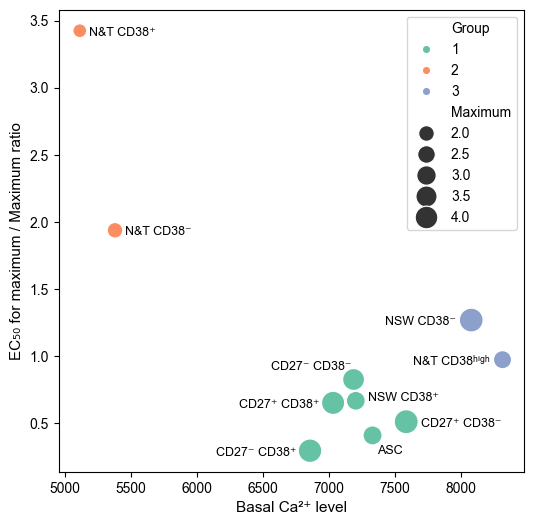

In [49]:
# plot
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x=df['basal'], y=df['ratio'], hue=df['Group'], palette='Set2', size=df['Maximum'], sizes=(100, 300))
plt.xlabel('Basal Ca\u00b2\u207a level', size=11)
plt.ylabel('EC\u2085\u2080 for maximum / Maximum ratio', size=11)

# add text to the plot
plt.text(df['basal'][0]+75, df['ratio'][0]-0.035, names[0], size=9)   # N&T CD38⁻
plt.text(df['basal'][1]+70, df['ratio'][1]-0.035, names[1], size=9)   # N&T CD38⁺
plt.text(df['basal'][2]-675, df['ratio'][2]-0.035, names[2], size=9)  # N&T CD38ʰⁱᵍʰ
plt.text(df['basal'][3]-650, df['ratio'][3]-0.035, names[3], size=9)  # NSW CD38⁻
plt.text(df['basal'][4]+90, df['ratio'][4], names[4], size=9)         # NSW CD38⁺
plt.text(df['basal'][5]+115, df['ratio'][5]-0.035, names[5], size=9)  # CD27⁺ CD38⁻
plt.text(df['basal'][6]-715, df['ratio'][6]-0.035, names[6], size=9)  # CD27⁺ CD38⁺
plt.text(df['basal'][7]+35, df['ratio'][7]-0.14, names[7], size=9)    # ASC
plt.text(df['basal'][8]-628, df['ratio'][8]+0.07, names[8], size=9)   # CD27⁻ CD38⁻
plt.text(df['basal'][9]-715, df['ratio'][9]-0.035, names[9], size=9)  # CD27⁻ CD38⁺

plt.savefig('ratio_scatterplot.jpg', bbox_inches='tight', dpi=600)